In [2]:
!pip install pandas matplotlib seaborn

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [4]:
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv"
df = pd.read_csv(url)

print(df.shape)
df.head()

(32833, 23)


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [5]:
df.to_csv("spotify_songs.csv", index=False)

In [6]:
# Check data types
print(df.dtypes)

track_id                        str
track_name                      str
track_artist                    str
track_popularity              int64
track_album_id                  str
track_album_name                str
track_album_release_date        str
playlist_name                   str
playlist_id                     str
playlist_genre                  str
playlist_subgenre               str
danceability                float64
energy                      float64
key                           int64
loudness                    float64
mode                          int64
speechiness                 float64
acousticness                float64
instrumentalness            float64
liveness                    float64
valence                     float64
tempo                       float64
duration_ms                   int64
dtype: object


In [7]:
# Check missing values
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values:
track_name          5
track_artist        5
track_album_name    5
dtype: int64


In [8]:
# Check fully duplicated rows
print("Fully duplicated rows:")
print(df.duplicated().sum())

Fully duplicated rows:
0


In [9]:
# Check duplicated track_id (a track can appear in multiple playlists)
print("Duplicate track_id count:")
print(df['track_id'].duplicated().sum())

Duplicate track_id count:
4477


In [10]:
# Drop rows with missing track/artist/album name (only ~5 rows)
df = df.dropna(subset=['track_name', 'track_artist', 'track_album_name'])

In [11]:
# Convert release date to datetime and extract year
df['track_album_release_date'] = pd.to_datetime(df['track_album_release_date'], errors='coerce')
df['release_year'] = df['track_album_release_date'].dt.year

In [12]:
print("Shape after cleaning:", df.shape)

Shape after cleaning: (32828, 24)


In [13]:
print("Release year cleaning:", df['release_year'].min(), "-", df['release_year'].max())

Release year cleaning: 1957.0 - 2020.0


In [14]:
# Create a version with unique track only (for track-level analysis)
df_unique = df.drop_duplicates(subset=['track_id'], keep='first')

In [15]:
print("Full dataset (track-playlist rows):", df.shape)

Full dataset (track-playlist rows): (32828, 24)


In [16]:
print("Unique tracks:", df_unique.shape)

Unique tracks: (28352, 24)


In [17]:
# Select numeric audio feature columns
audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                   'acousticness', 'instrumentalness', 'liveness',
                   'valence', 'tempo', 'duration_ms', 'track_popularity']
# Compute correlation matrix
corr_matrix = df_unique[audio_features].corr()

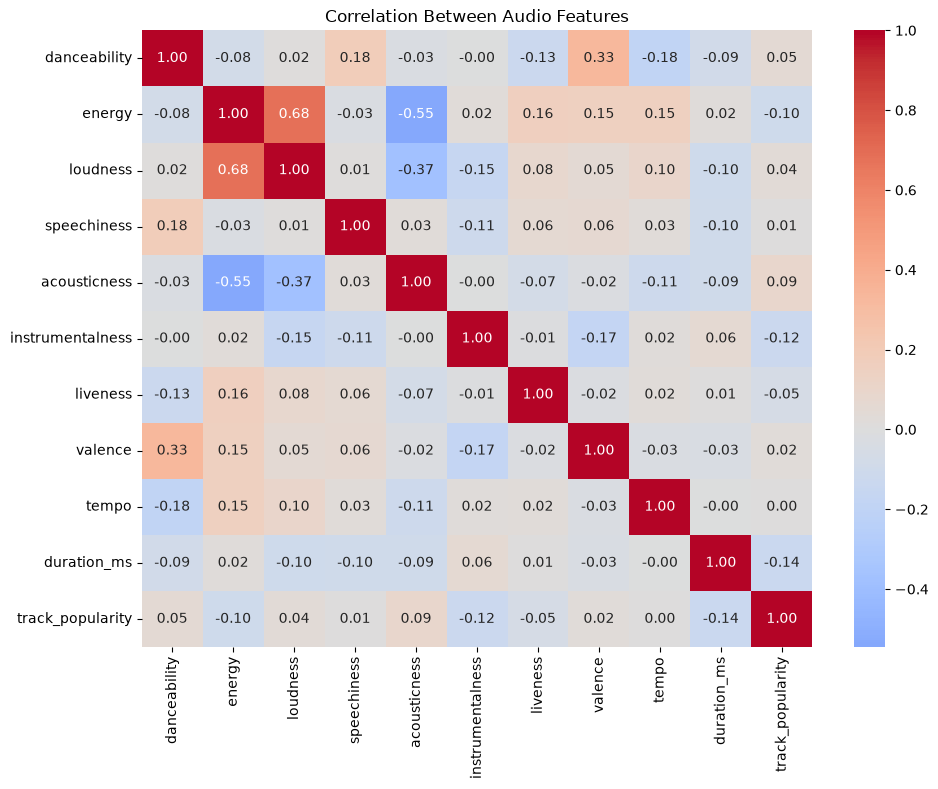

In [18]:
# plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Between Audio Features")
plt.tight_layout()
plt.show()

In [19]:
# Compare average audio features across genres
genre_avg = df.groupby('playlist_genre')[audio_features].mean().round(2)

In [20]:
genre_avg

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,track_popularity
playlist_genre,,,,,,,,,,,
edm,0.66,0.80,-5.43,0.09,0.08,0.22,0.21,0.40,125.77,222540.86,34.83
latin,0.71,0.71,-6.26,0.10,0.21,0.04,0.18,0.61,118.63,216843.70,47.04
pop,0.64,0.70,-6.32,0.07,0.17,0.06,0.18,0.50,120.74,217768.10,47.74
r&b,0.67,0.59,-7.86,0.12,0.26,0.03,0.18,0.53,114.22,237599.49,41.22
rap,0.72,0.65,-7.04,0.20,0.19,0.08,0.19,0.51,120.66,214155.37,43.24
rock,0.52,0.73,-7.59,0.06,0.15,0.06,0.20,0.54,124.99,248576.50,41.73


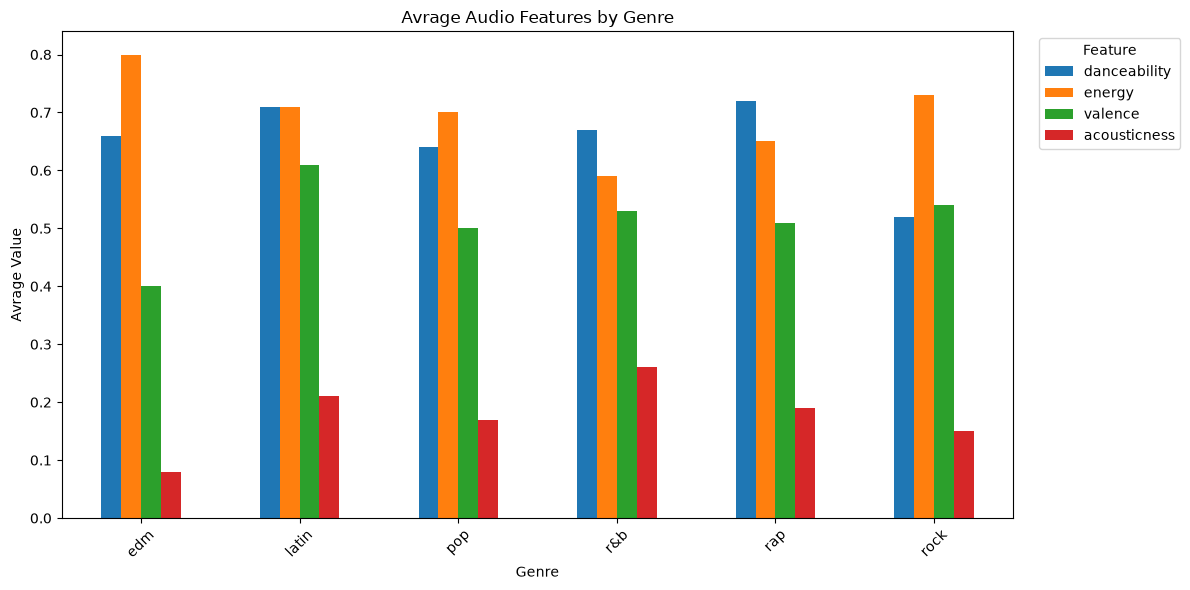

In [21]:
# Compare key audio features across genres using a grouped bar chart
key_features = ['danceability', 'energy', 'valence', 'acousticness']

genre_avg[key_features].plot(kind='bar', figsize=(12, 6))
plt.title("Avrage Audio Features by Genre")
plt.xlabel("Genre")
plt.ylabel("Avrage Value")
plt.xticks(rotation=45)
plt.legend(title="Feature", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

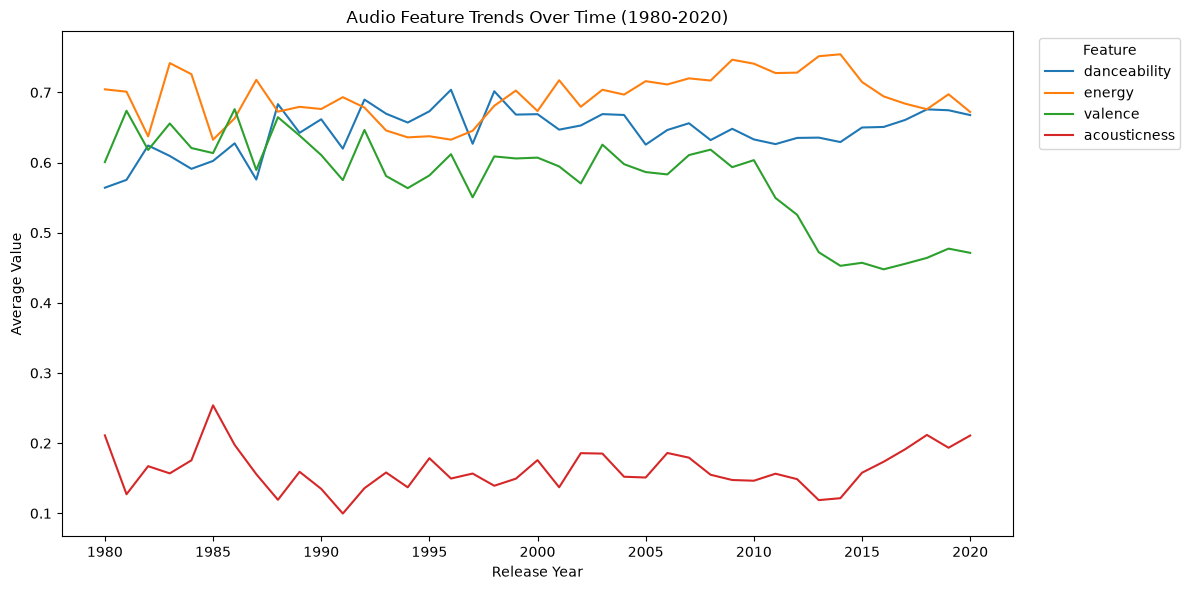

In [22]:
# Analyze trend of audio features over release years (using unique tracks)
# Filter to a reasonable range since older years have very few tracks
yearly_trend = df_unique[df_unique['release_year'] >= 1980].groupby('release_year')[key_features].mean()

yearly_trend.plot(figsize=(12, 6))
plt.title("Audio Feature Trends Over Time (1980-2020)")
plt.xlabel("Release Year")
plt.ylabel("Average Value")
plt.legend(title="Feature", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

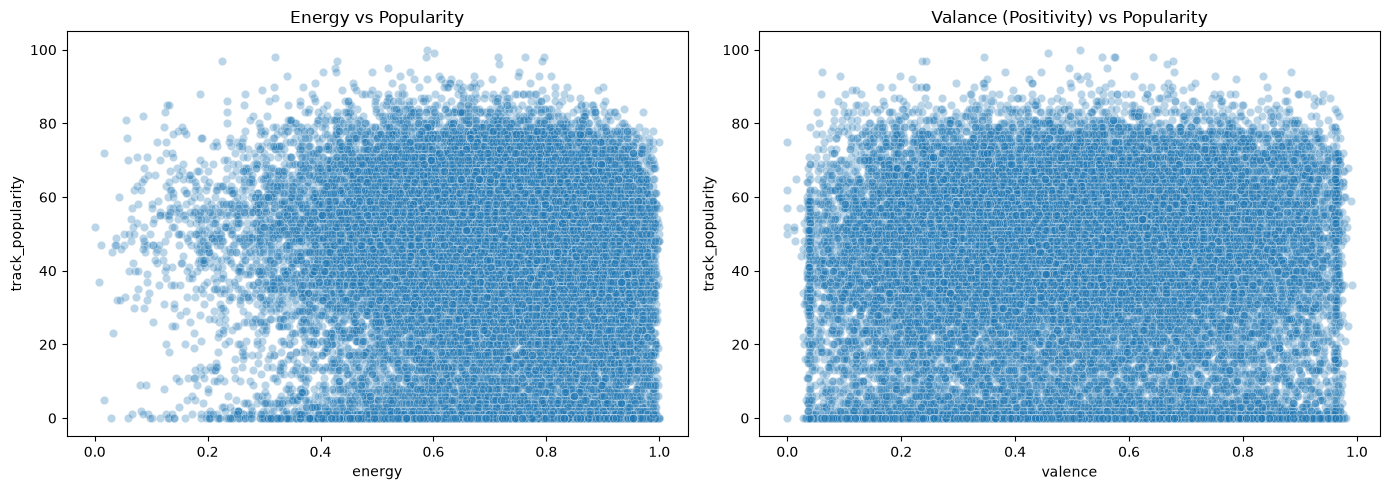

In [23]:
# Scatter plot: does energy or valence relate to popularity?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df_unique, x='energy', y='track_popularity', alpha=0.3, ax=axes[0])
axes[0].set_title("Energy vs Popularity")

sns.scatterplot(data=df_unique, x='valence', y='track_popularity', alpha=0.3, ax=axes[1])
axes[1].set_title("Valance (Positivity) vs Popularity")

plt.tight_layout()
plt.show()

In [27]:
# Find top by average popularity (only artists with at least 5 tracks)
artist_stats = df_unique.groupby('track_artist').agg(
    avg_popularity=('track_popularity', 'mean'),
    track_count=('track_id', 'count')
)

top_artists = artist_stats[artist_stats['track_count'] >= 5].sort_values(
    'avg_popularity', ascending=False
).head(10)

top_artists

,avg_popularity,track_count
track_artist,,
DaBaby,83.666667,6
Roddy Ricch,83.428571,7
Harry Styles,81.777778,9
YNW Melly,81.571429,7
Billie Eilish,76.961538,26
Lewis Capaldi,76.888889,9
Alec Benjamin,76.833333,6
Dimelo Flow,76.800000,5
Rich Music LTD,76.500000,6


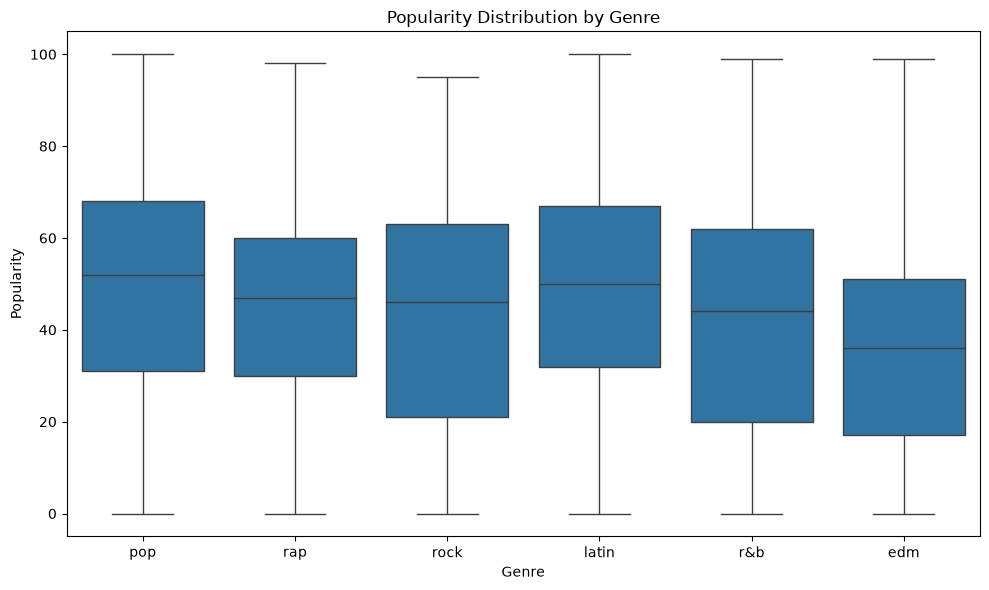

In [29]:
# Distribution of popularity across genres
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='playlist_genre', y='track_popularity')
plt.title("Popularity Distribution by Genre")
plt.xlabel("Genre")
plt.ylabel("Popularity")
plt.tight_layout()
plt.show()

## Conclusion

- Energy and loudness are strongly positively correlated, while energy and acousticness are strongly negatively correlated.
- EDM has the highest average energy, while rap has the highest average danceability.
- Audio features like energy and acousticness show opposite trends over time (1980-2020).
- Pop tracks tend to have the highest popularity among genres.